## Required Preprocessing

In [ ]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.patches as mpatches
from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)
from sklearn.decomposition import PCA
from statsmodels.tsa.seasonal import seasonal_decompose

In [ ]:
df=pd.read_csv("/content/patient_vitals.csv")
df.head(5)

,PatientID,Timestamp,HeartRate,BloodPressureSystolic,BloodPressureDiastolic,BloodOxygenLevel,BodyTemperature,RespiratoryRate,SleepHours,StressLevel,Age,Gender,Diagnosis
0,P0001,2024-01-01 00:00:00,83.2,153.9,90.6,96.3,36.58,16.0,6.2,6,38,M,Hypertension
1,P0001,2024-01-01 06:00:00,81.2,172.5,110.3,95.0,36.88,16.5,5.8,3,38,M,Hypertension
2,P0001,2024-01-01 12:00:00,94.9,154.7,100.8,97.3,36.95,16.4,6.0,6,38,M,Hypertension
3,P0001,2024-01-01 18:00:00,86.6,153.3,97.7,96.4,36.47,18.9,7.6,5,38,M,Hypertension
4,P0001,2024-01-02 00:00:00,83.8,140.7,94.7,96.6,37.16,17.6,4.6,2,38,M,Hypertension


In [ ]:
critical = ["PatientID", "Timestamp", "Diagnosis"]
null_report = df[critical].isnull().sum()
print("\nNull counts in critical columns:")
print(null_report)
if null_report.sum() == 0:
    print("  → No anomalies found in critical columns.")


Null counts in critical columns:
PatientID    0
Timestamp    0
Diagnosis    0
dtype: int64
  → No anomalies found in critical columns.


In [ ]:
# 3. Physiological range filters
ranges = {
    "HeartRate":              (40,  180),
    "BloodPressureSystolic":  (80,  200),
    "BloodPressureDiastolic": (50,  130),
    "BloodOxygenLevel":       (85,  100),
    "BodyTemperature":        (35.5, 41.0),
    "RespiratoryRate":        (10,   40),
    "SleepHours":             (2,    12),
    "StressLevel":            (1,    10),
}
print("\nRows dropped per physiological filter:")
df_clean = df.copy()
for col, (lo, hi) in ranges.items():
    before = len(df_clean)
    df_clean = df_clean[(df_clean[col] >= lo) & (df_clean[col] <= hi)]
    dropped = before - len(df_clean)
    print(f"  {col:30s}: {dropped} rows dropped")


Rows dropped per physiological filter:
  HeartRate                     : 126 rows dropped
  BloodPressureSystolic         : 12 rows dropped
  BloodPressureDiastolic        : 8 rows dropped
  BloodOxygenLevel              : 0 rows dropped
  BodyTemperature               : 8 rows dropped
  RespiratoryRate               : 634 rows dropped
  SleepHours                    : 0 rows dropped
  StressLevel                   : 0 rows dropped


In [ ]:
# 4. Sort
df_clean = df_clean.sort_values(["PatientID", "Timestamp"]).reset_index(drop=True)

# 5. Per-patient time series
patient_ts = {pid: grp.set_index("Timestamp") for pid, grp in df_clean.groupby("PatientID")}

In [ ]:
# 6. Patient-level feature matrix
vital_cols = ["HeartRate", "BloodPressureSystolic", "BloodPressureDiastolic",
              "BloodOxygenLevel", "BodyTemperature", "RespiratoryRate",
              "SleepHours", "StressLevel"]

def trend_slope(series):
    if len(series) < 2:
        return 0.0
    x = np.arange(len(series))
    return np.polyfit(x, series.values, 1)[0]

feature_rows = []
for pid, grp in df_clean.groupby("PatientID"):
    row = {"PatientID": pid, "Diagnosis": grp["Diagnosis"].iloc[0]}
    for col in vital_cols:
        s = grp[col]
        row[f"{col}_mean"] = s.mean()
        row[f"{col}_std"]  = s.std()
        row[f"{col}_min"]  = s.min()
        row[f"{col}_max"]  = s.max()
        row[f"{col}_slope"]= trend_slope(s)
    feature_rows.append(row)

feat_df = pd.DataFrame(feature_rows)


In [ ]:
print("Total Rows:", len(df))
print("Unique Patients:", df['PatientID'].nunique())

class_dist = df['Diagnosis'].value_counts()
print(class_dist)
print(class_dist / len(df) * 100)

print("Date Range:", df['Timestamp'].min(), "to", df['Timestamp'].max())

avg_readings = df.groupby('PatientID').size().mean()
print("Avg readings per patient:", avg_readings)

Total Rows: 60000
Unique Patients: 500
Diagnosis
Healthy           19680
Hypertension      14760
Diabetes          11280
Arrhythmia         9600
Sleep Disorder     4680
Name: count, dtype: int64
Diagnosis
Healthy           32.8
Hypertension      24.6
Diabetes          18.8
Arrhythmia        16.0
Sleep Disorder     7.8
Name: count, dtype: float64
Date Range: 2024-01-01 00:00:00 to 2024-01-30 18:00:00
Avg readings per patient: 120.0


# PART A: TIME SERIES ANALYSIS & TREND DETECTION

##  A1: Visualisation & Descriptive Statistics

Healthy Mean: 72.9825 Std: 7.64314008350851 Min: 56.5 Max: 95.7 CV: 10.472565455429054
Hypertension Mean: 81.21666666666667 Std: 9.938561968695584 Min: 57.2 Max: 106.2 CV: 12.23709661649364
Arrhythmia Mean: 89.81416666666668 Std: 24.460825466304215 Min: 25.0 Max: 154.7 CV: 27.234930049607108


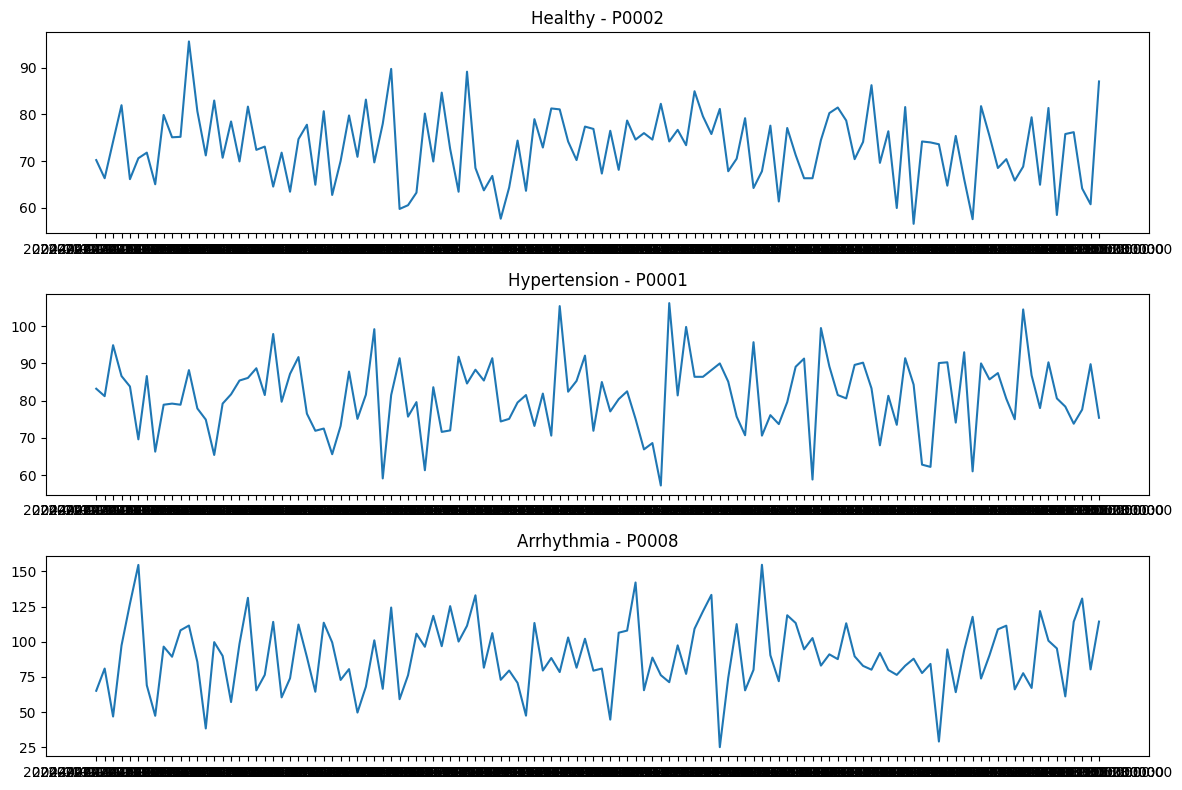

In [ ]:
patients = {
    "Healthy": df[df['Diagnosis']=="Healthy"]['PatientID'].unique()[0],
    "Hypertension": df[df['Diagnosis']=="Hypertension"]['PatientID'].unique()[0],
    "Arrhythmia": df[df['Diagnosis']=="Arrhythmia"]['PatientID'].unique()[0],
}

plt.figure(figsize=(12,8))

for i,(label,pid) in enumerate(patients.items()):
    sub = df[df['PatientID']==pid]

    plt.subplot(3,1,i+1)
    plt.plot(sub['Timestamp'], sub['HeartRate'])
    plt.title(f"{label} - {pid}")

    stats = sub['HeartRate']
    mean = stats.mean()
    std = stats.std()
    cv = (std/mean)*100

    print(label, "Mean:",mean,"Std:",std,"Min:",stats.min(),"Max:",stats.max(),"CV:",cv)

plt.tight_layout()
plt.show()

## A2:Trend Analysis with Moving Averages &amp; Decomposition

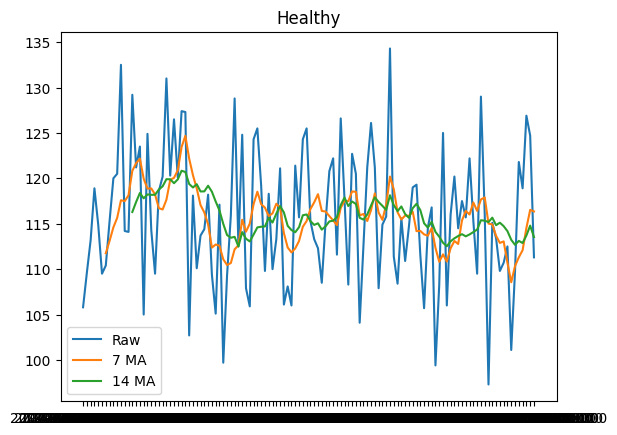

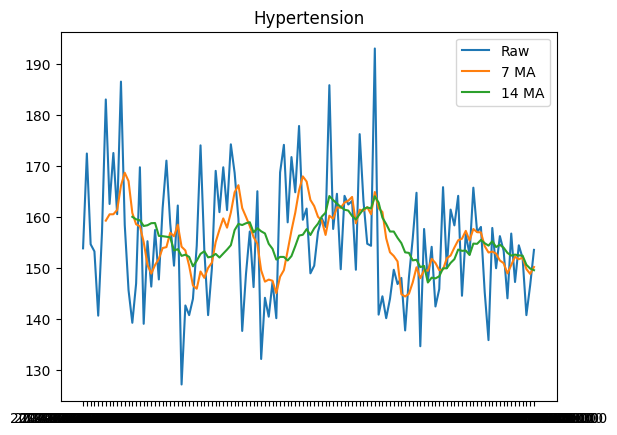

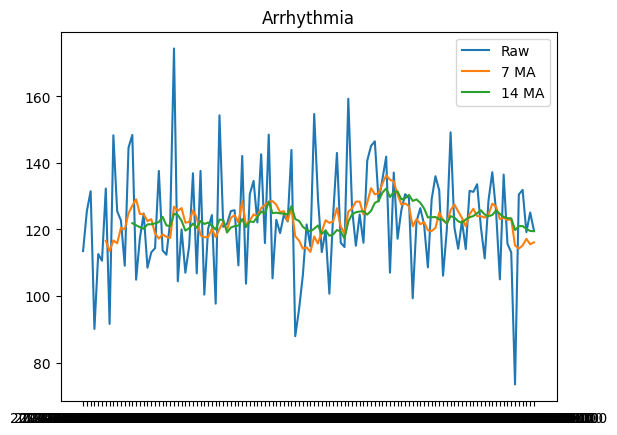

In [ ]:
for label,pid in patients.items():
    sub = df[df['PatientID']==pid]

    sub['roll7'] = sub['BloodPressureSystolic'].rolling(7).mean()
    sub['roll14'] = sub['BloodPressureSystolic'].rolling(14).mean()

    plt.figure()
    plt.plot(sub['Timestamp'], sub['BloodPressureSystolic'], label="Raw")
    plt.plot(sub['Timestamp'], sub['roll7'], label="7 MA")
    plt.plot(sub['Timestamp'], sub['roll14'], label="14 MA")
    plt.legend()
    plt.title(label)
    plt.show()

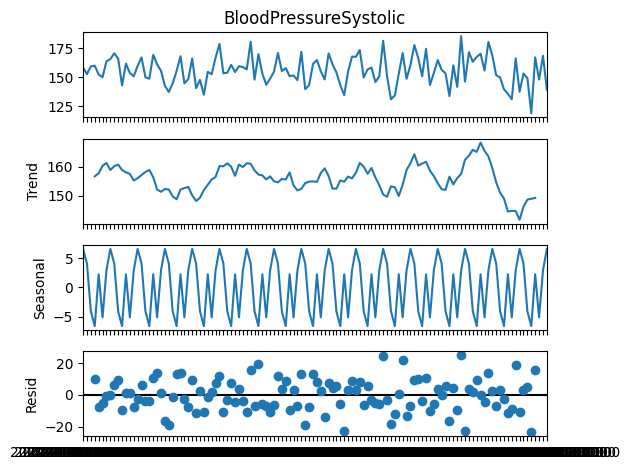

In [ ]:
long_patient = df['PatientID'].value_counts().idxmax()
series = df[df['PatientID']==long_patient].set_index('Timestamp')['BloodPressureSystolic']

decomp = seasonal_decompose(series, model='additive', period=7)

decomp.plot()
plt.show()

## A3.Anomaly Detection via Statistical Thresholding

In [ ]:
df['Anomaly'] = False

for pid, group in df.groupby("PatientID"):
    mu = group['HeartRate'].mean()
    sigma = group['HeartRate'].std()

    condition = (group['HeartRate'] > mu + 2*sigma) | (group['HeartRate'] < mu - 2*sigma)
    df.loc[group.index, 'Anomaly'] = condition

total_anomalies = df['Anomaly'].sum()
print("Total anomalies:", total_anomalies)

print(df.groupby('Diagnosis')['Anomaly'].mean()*100)

Total anomalies: 2685
Diagnosis
Arrhythmia        4.385417
Diabetes          4.485816
Healthy           4.517276
Hypertension      4.424119
Sleep Disorder    4.615385
Name: Anomaly, dtype: float64


In [ ]:
top5 = df.groupby('PatientID')['Anomaly'].sum().sort_values(ascending=False).head(5)

print("\nTop 5 Patients with most anomalies:")
for pid, count in top5.items():
    diagnosis = df[df['PatientID']==pid]['Diagnosis'].iloc[0]
    print(f"{pid} | {diagnosis} | {count} anomalies")


Top 5 Patients with most anomalies:
P0128 | Arrhythmia | 10 anomalies
P0348 | Healthy | 9 anomalies
P0344 | Hypertension | 9 anomalies
P0095 | Arrhythmia | 9 anomalies
P0206 | Diabetes | 9 anomalies


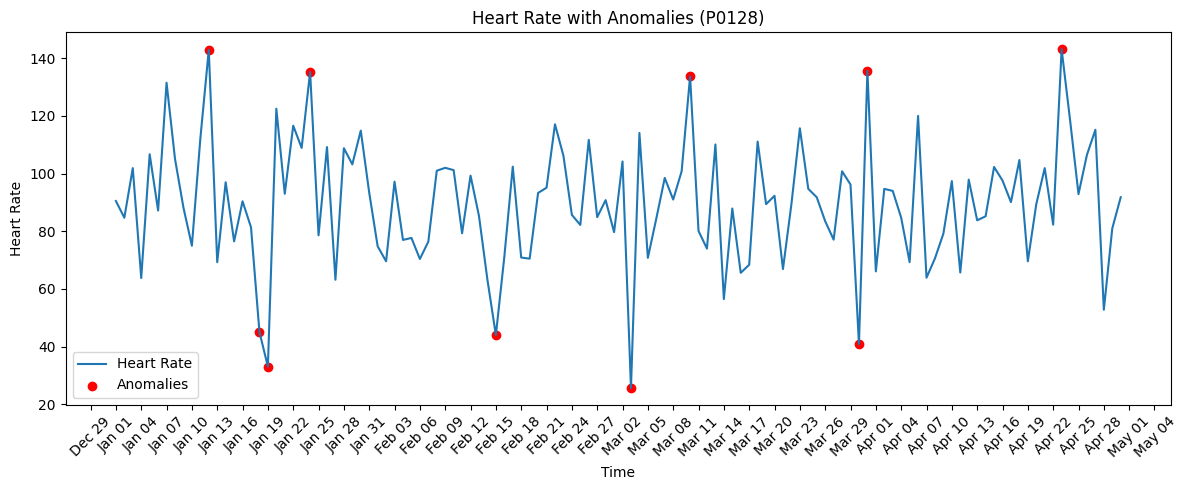

In [ ]:
top_patient = top5.index[0]
sub = df[df['PatientID'] == top_patient]

plt.figure(figsize=(12,5))
import matplotlib.dates as mdates
# Line plot
plt.plot(sub['Timestamp'], sub['HeartRate'], label="Heart Rate")

# Anomalies
anomalies = sub[sub['Anomaly'] == True]
plt.scatter(anomalies['Timestamp'], anomalies['HeartRate'],
            color='red', label='Anomalies')

#  FORMAT TIME AXIS
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=3))  # show every 3 days
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

plt.xticks(rotation=45)

plt.title(f"Heart Rate with Anomalies ({top_patient})")
plt.xlabel("Time")
plt.ylabel("Heart Rate")
plt.legend()

plt.tight_layout()
plt.show()

## PART B — Similarity Search

## B1.— Distance Metrics

In [ ]:
features = []

for pid, group in df.groupby("PatientID"):
    record = {}

    record['PatientID'] = pid   # ✅ KEEP THIS
    record['Diagnosis'] = group['Diagnosis'].iloc[0]

    for col in ['HeartRate','BloodPressureSystolic','BloodPressureDiastolic',
                'BloodOxygenLevel','BodyTemperature','RespiratoryRate',
                'SleepHours','StressLevel']:

        record[col+"_mean"] = group[col].mean()
        record[col+"_std"] = group[col].std()
        record[col+"_min"] = group[col].min()
        record[col+"_max"] = group[col].max()

        from scipy.stats import linregress
        record[col+"_trend"] = linregress(range(len(group)), group[col])[0]

    features.append(record)

feature_df = pd.DataFrame(features)

In [ ]:
from sklearn.preprocessing import StandardScaler

X = feature_df.drop(["PatientID","Diagnosis"], axis=1)
y = feature_df["Diagnosis"]
ids = feature_df["PatientID"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
import random
from sklearn.metrics.pairwise import euclidean_distances, manhattan_distances
indices = random.sample(range(len(X_scaled)), 10)
results = []

for idx in indices:
    query_id = ids.iloc[idx]
    query_class = y.iloc[idx]

    query = X_scaled[idx].reshape(1, -1)

    euc_dist = euclidean_distances(query, X_scaled)[0]
    man_dist = manhattan_distances(query, X_scaled)[0]

    # get nearest neighbors (exclude itself)
    euc_nn = np.argsort(euc_dist)[1:4]
    man_nn = np.argsort(man_dist)[1:4]

    # store results
    results.append({
        "Query": query_id,
        "Metric": "Euclidean",
        "NN1": (ids.iloc[euc_nn[0]], y.iloc[euc_nn[0]], round(euc_dist[euc_nn[0]],2)),
        "NN2": (ids.iloc[euc_nn[1]], y.iloc[euc_nn[1]], round(euc_dist[euc_nn[1]],2)),
        "NN3": (ids.iloc[euc_nn[2]], y.iloc[euc_nn[2]], round(euc_dist[euc_nn[2]],2)),
    })

    results.append({
        "Query": query_id,
        "Metric": "Manhattan",
        "NN1": (ids.iloc[man_nn[0]], y.iloc[man_nn[0]], round(man_dist[man_nn[0]],2)),
        "NN2": (ids.iloc[man_nn[1]], y.iloc[man_nn[1]], round(man_dist[man_nn[1]],2)),
        "NN3": (ids.iloc[man_nn[2]], y.iloc[man_nn[2]], round(man_dist[man_nn[2]],2)),
    })

results_df = pd.DataFrame(results)
results_df

,Query,Metric,NN1,NN2,NN3
0,P0363,Euclidean,"(P0350, Arrhythmia, 3.76)","(P0408, Arrhythmia, 4.04)","(P0198, Arrhythmia, 4.13)"
1,P0363,Manhattan,"(P0408, Arrhythmia, 16.9)","(P0350, Arrhythmia, 17.34)","(P0198, Arrhythmia, 18.32)"
2,P0440,Euclidean,"(P0458, Sleep Disorder, 3.51)","(P0028, Sleep Disorder, 4.12)","(P0389, Sleep Disorder, 4.14)"
3,P0440,Manhattan,"(P0458, Sleep Disorder, 15.26)","(P0028, Sleep Disorder, 17.64)","(P0389, Sleep Disorder, 18.68)"
4,P0492,Euclidean,"(P0042, Healthy, 2.22)","(P0417, Healthy, 2.53)","(P0135, Healthy, 2.65)"
5,P0492,Manhattan,"(P0135, Healthy, 10.52)","(P0042, Healthy, 10.94)","(P0165, Healthy, 11.24)"
6,P0130,Euclidean,"(P0107, Sleep Disorder, 4.57)","(P0264, Sleep Disorder, 4.75)","(P0069, Sleep Disorder, 4.87)"
7,P0130,Manhattan,"(P0264, Sleep Disorder, 16.9)","(P0069, Sleep Disorder, 19.02)","(P0385, Sleep Disorder, 19.51)"
8,P0148,Euclidean,"(P0203, Diabetes, 3.06)","(P0143, Diabetes, 3.27)","(P0038, Diabetes, 3.54)"
9,P0148,Manhattan,"(P0203, Diabetes, 12.71)","(P0143, Diabetes, 13.79)","(P0228, Diabetes, 14.97)"


## B2.— DTW-Based Similarity on Raw Time Series

In [ ]:
!pip install dtaidistance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 24.2 MB/s eta 0:00:00


In [ ]:
from dtaidistance import dtw

series_dict = {}
class_dict = {}

for pid, group in df.groupby("PatientID"):
    hr = group['HeartRate'].values

    if len(hr) >= 20:
        seq = hr[:20]   # take first 20
        series_dict[pid] = seq
        class_dict[pid] = group['Diagnosis'].iloc[0]

patients = list(series_dict.keys())

n = len(patients)
dtw_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        dtw_matrix[i, j] = dtw.distance(series_dict[patients[i]],
                                        series_dict[patients[j]])

In [ ]:
queries = {}

for cls in ["Healthy","Hypertension","Arrhythmia"]:
    for pid in patients:
        if class_dict[pid] == cls:
            queries[cls] = pid
            break

queries
for cls, qid in queries.items():
    idx = patients.index(qid)

    distances = dtw_matrix[idx]
    nearest = np.argsort(distances)[1:4]  # skip itself

    print(f"\nQuery Patient: {qid} ({cls})")

    for i in nearest:
        pid = patients[i]
        print(f"Neighbor: {pid}, Class: {class_dict[pid]}, Distance: {round(distances[i],2)}")


Query Patient: P0002 (Healthy)
Neighbor: P0263, Class: Healthy, Distance: 20.57
Neighbor: P0007, Class: Healthy, Distance: 20.98
Neighbor: P0080, Class: Healthy, Distance: 21.15

Query Patient: P0001 (Hypertension)
Neighbor: P0159, Class: Hypertension, Distance: 20.39
Neighbor: P0374, Class: Hypertension, Distance: 21.04
Neighbor: P0021, Class: Hypertension, Distance: 21.4

Query Patient: P0008 (Arrhythmia)
Neighbor: P0485, Class: Arrhythmia, Distance: 69.93
Neighbor: P0178, Class: Arrhythmia, Distance: 78.17
Neighbor: P0196, Class: Arrhythmia, Distance: 80.96


DTW demonstrated stronger alignment with patients from the same Diagnosis class compared to Euclidean distance. This is because DTW accounts for temporal shifts and variations in heart rate patterns over time

## B3 — Clinical Similarity Application

In [ ]:
query_dict = {
    "HeartRate_mean": 98,
    "HeartRate_std": 18,
    "BloodPressureSystolic_mean": 155,
    "BloodPressureSystolic_std": 12,
    "BloodOxygenLevel_mean": 94,
    "SleepHours_mean": 4.5
}
query = []

for col in X.columns:
    if col in query_dict:
        query.append(query_dict[col])
    else:
        query.append(0)  # fill missing features

query = np.array(query).reshape(1, -1)
query_scaled = scaler.transform(query)
from sklearn.metrics.pairwise import euclidean_distances

distances = euclidean_distances(query_scaled, X_scaled)[0]
nearest = np.argsort(distances)[:5]

neighbors = [(ids.iloc[i], y.iloc[i], round(distances[i],2)) for i in nearest]
neighbors
classes = [cls for _, cls, _ in neighbors]

from collections import Counter
count = Counter(classes)

predicted_class = count.most_common(1)[0][0]
confidence = count.most_common(1)[0][1] / 5

print("Prediction:", predicted_class)
print("Confidence:", confidence)
print("Neighbors:", neighbors)

Prediction: Healthy
Confidence: 0.8
Neighbors: [('P0491', 'Sleep Disorder', np.float64(467.32)), ('P0024', 'Healthy', np.float64(467.88)), ('P0328', 'Healthy', np.float64(467.99)), ('P0494', 'Healthy', np.float64(468.01)), ('P0480', 'Healthy', np.float64(468.18))]


## Part C: Supervised Classification

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42)

## C1. — Decision Tree

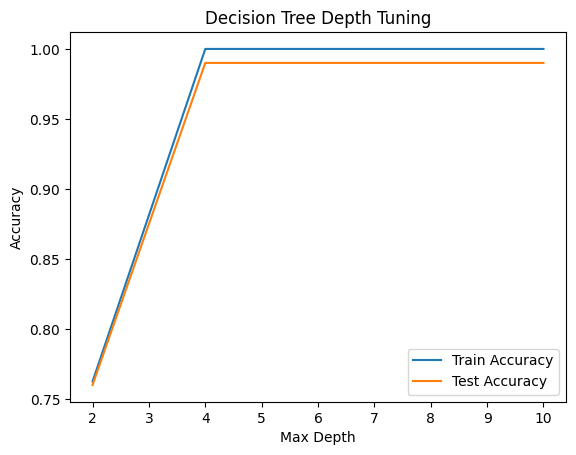

Best depth: 4


In [ ]:
depths = [2, 4, 6, 8, 10]
train_acc = []
val_acc = []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, criterion="gini", random_state=42)
    clf.fit(X_train, y_train)

    train_acc.append(accuracy_score(y_train, clf.predict(X_train)))
    val_acc.append(accuracy_score(y_test, clf.predict(X_test)))

plt.plot(depths, train_acc, label="Train Accuracy")
plt.plot(depths, val_acc, label="Test Accuracy")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Decision Tree Depth Tuning")
plt.show()

best_depth = depths[np.argmax(val_acc)]
print("Best depth:", best_depth)

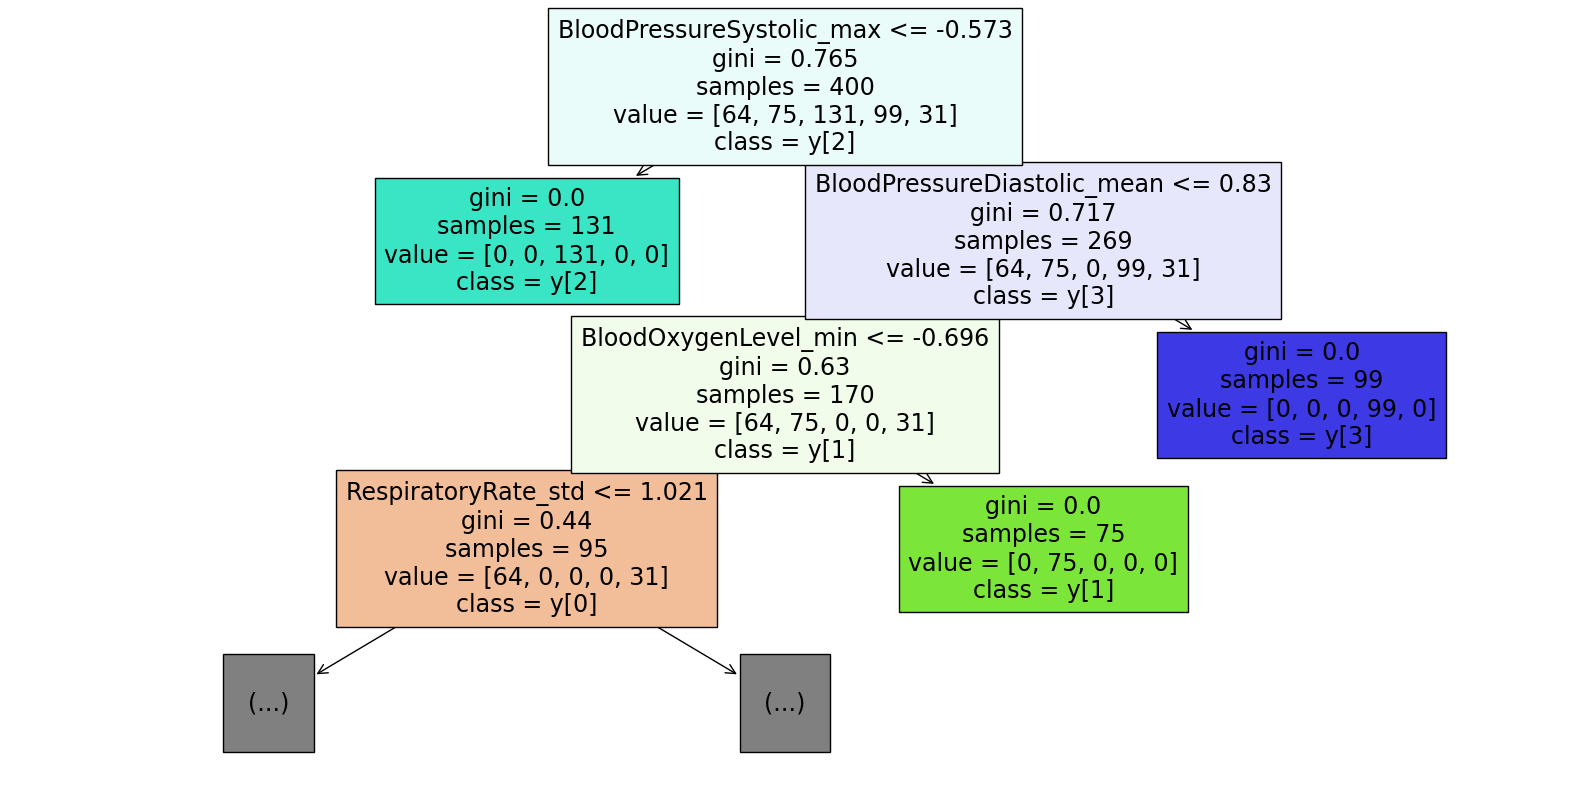

In [ ]:
dt = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
plt.figure(figsize=(20,10))
plot_tree(
    dt,
    max_depth=3,

feature_names=X.columns,
    class_names=True,
    filled=True
)
plt.show()

BloodPressureSystolic_max      0.369528
BloodPressureDiastolic_mean    0.280134
BloodOxygenLevel_min           0.213790
RespiratoryRate_std            0.136547
HeartRate_mean                 0.000000
dtype: float64


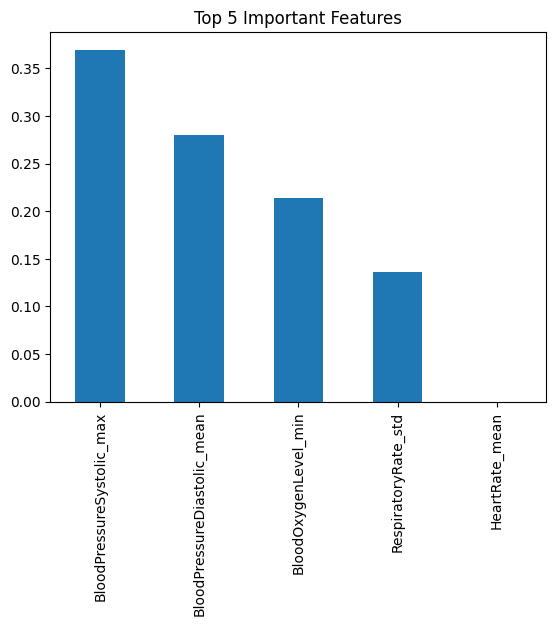

In [ ]:
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
importances = pd.Series(dt.feature_importances_, index=X_train.columns)

top5 = importances.sort_values(ascending=False).head(5)

print(top5)

top5.plot(kind="bar")
plt.title("Top 5 Important Features")
plt.show()

## C2.— Rule-Based Classification

In [ ]:
from sklearn.tree import _tree
feature_names = X_train.columns
class_names = dt.classes_

def extract_rules(tree, feature_names):
    tree_ = tree.tree_
    rules = []

    def recurse(node, path):
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            name = feature_names[tree_.feature[node]]
            threshold = tree_.threshold[node]

            recurse(tree_.children_left[node],
                    path + [f"{name} <= {threshold:.3f}"])
            recurse(tree_.children_right[node],
                    path + [f"{name} > {threshold:.3f}"])
        else:
            value = tree_.value[node][0]
            predicted_class = class_names[np.argmax(value)]
            rules.append((path, predicted_class))

    recurse(0, [])
    return rules

rules = extract_rules(dt, feature_names)

print(f"Total rules extracted: {len(rules)}")

Total rules extracted: 5


In [ ]:
def evaluate_rules(rules, X, y):
    results = []

    for conds, pred_class in rules:
        mask = np.ones(len(X), dtype=bool)

        for cond in conds:
            feature, op, value = cond.split()
            value = float(value)

            if op == "<=":
                mask &= (X[feature] <= value)
            else:
                mask &= (X[feature] > value)

        if mask.sum() == 0:
            continue

        coverage = mask.mean() * 100
        accuracy = (y[mask] == pred_class).mean() * 100

        results.append({
            "rule": conds,
            "class": pred_class,
            "coverage": coverage,
            "accuracy": accuracy
        })

    return pd.DataFrame(results)

rule_df = evaluate_rules(rules, X_train, y_train)
rule_df = rule_df.sort_values(by="accuracy", ascending=False)

rule_df.head(10)

,rule,class,coverage,accuracy
0,[BloodPressureSystolic_max <= -0.573],Healthy,32.75,100.0
1,"[BloodPressureSystolic_max > -0.573, BloodPres...",Sleep Disorder,7.75,100.0
2,"[BloodPressureSystolic_max > -0.573, BloodPres...",Arrhythmia,16.00,100.0
3,"[BloodPressureSystolic_max > -0.573, BloodPres...",Diabetes,18.75,100.0
4,"[BloodPressureSystolic_max > -0.573, BloodPres...",Hypertension,24.75,100.0


In [ ]:
def print_rules(df, n=10):
    for i, row in df.head(n).iterrows():
        conditions = " AND ".join(row["rule"])
        print(f"IF {conditions} THEN Diagnosis = {row['class']} "
              f"(coverage: {row['coverage']:.2f}%, accuracy: {row['accuracy']:.2f}%)")

print_rules(rule_df, 10)

IF BloodPressureSystolic_max <= -0.573 THEN Diagnosis = Healthy (coverage: 32.75%, accuracy: 100.00%)
IF BloodPressureSystolic_max > -0.573 AND BloodPressureDiastolic_mean <= 0.830 AND BloodOxygenLevel_min <= -0.696 AND RespiratoryRate_std <= 1.021 THEN Diagnosis = Sleep Disorder (coverage: 7.75%, accuracy: 100.00%)
IF BloodPressureSystolic_max > -0.573 AND BloodPressureDiastolic_mean <= 0.830 AND BloodOxygenLevel_min <= -0.696 AND RespiratoryRate_std > 1.021 THEN Diagnosis = Arrhythmia (coverage: 16.00%, accuracy: 100.00%)
IF BloodPressureSystolic_max > -0.573 AND BloodPressureDiastolic_mean <= 0.830 AND BloodOxygenLevel_min > -0.696 THEN Diagnosis = Diabetes (coverage: 18.75%, accuracy: 100.00%)
IF BloodPressureSystolic_max > -0.573 AND BloodPressureDiastolic_mean > 0.830 THEN Diagnosis = Hypertension (coverage: 24.75%, accuracy: 100.00%)


## C3. k-Nearest Neighbour (kNN)

In [ ]:
from sklearn.impute import SimpleImputer
X = feature_df.drop(["PatientID","Diagnosis"], axis=1)
y = feature_df["Diagnosis"]

feature_names = X.columns

# Handle missing values
imputer = SimpleImputer(strategy="mean")
X = pd.DataFrame(imputer.fit_transform(X), columns=feature_names)

# Scale data
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_names)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

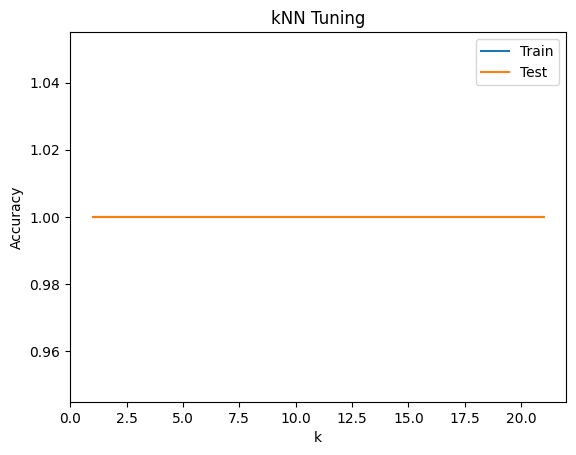

=== kNN ===
                precision    recall  f1-score   support

    Arrhythmia       1.00      1.00      1.00        16
      Diabetes       1.00      1.00      1.00        19
       Healthy       1.00      1.00      1.00        33
  Hypertension       1.00      1.00      1.00        24
Sleep Disorder       1.00      1.00      1.00         8

      accuracy                           1.00       100
     macro avg       1.00      1.00      1.00       100
  weighted avg       1.00      1.00      1.00       100



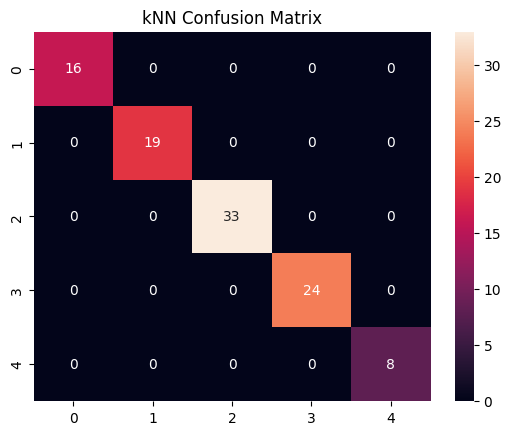

In [ ]:
ks = [1,3,5,7,9,11,15,21]
train_acc = []
test_acc = []

for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    train_acc.append(knn.score(X_train, y_train))
    test_acc.append(knn.score(X_test, y_test))

plt.plot(ks, train_acc, label="Train")
plt.plot(ks, test_acc, label="Test")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.legend()
plt.title("kNN Tuning")
plt.show()

best_k = ks[np.argmax(test_acc)]

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("=== kNN ===")
print(classification_report(y_test, y_pred_knn))
import seaborn as sns
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt="d")
plt.title("kNN Confusion Matrix")
plt.show()


## C4— Naïve Bayes Classification

In [ ]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

print(classification_report(y_test, y_pred_nb))
print(confusion_matrix(y_test, y_pred_nb))

                precision    recall  f1-score   support

    Arrhythmia       1.00      0.94      0.97        16
      Diabetes       1.00      1.00      1.00        19
       Healthy       1.00      1.00      1.00        33
  Hypertension       0.96      1.00      0.98        24
Sleep Disorder       1.00      1.00      1.00         8

      accuracy                           0.99       100
     macro avg       0.99      0.99      0.99       100
  weighted avg       0.99      0.99      0.99       100

[[15  0  0  1  0]
 [ 0 19  0  0  0]
 [ 0  0 33  0  0]
 [ 0  0  0 24  0]
 [ 0  0  0  0  8]]


## C5.  — Support Vector Machine (SVM)

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

params = [
    {'kernel': ['rbf'], 'C': [0.1, 1, 10, 100]},
    {'kernel': ['poly'], 'degree': [3], 'C': [0.1, 1, 10, 100]}
]

svc = GridSearchCV(SVC(), params, cv=5)
svc.fit(X_train, y_train)

print("Best Params:", svc.best_params_)

y_pred_svm = svc.predict(X_test)

print(classification_report(y_test, y_pred_svm))
print(confusion_matrix(y_test, y_pred_svm))

Best Params: {'C': 1, 'kernel': 'rbf'}
                precision    recall  f1-score   support

    Arrhythmia       1.00      1.00      1.00        16
      Diabetes       1.00      1.00      1.00        19
       Healthy       1.00      1.00      1.00        33
  Hypertension       1.00      1.00      1.00        24
Sleep Disorder       1.00      1.00      1.00         8

      accuracy                           1.00       100
     macro avg       1.00      1.00      1.00       100
  weighted avg       1.00      1.00      1.00       100

[[16  0  0  0  0]
 [ 0 19  0  0  0]
 [ 0  0 33  0  0]
 [ 0  0  0 24  0]
 [ 0  0  0  0  8]]


## Classifier Comparison [Part C, all sub-parts]

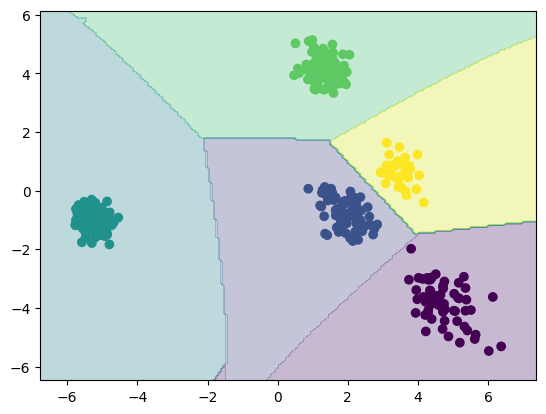

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)

svm_2d = SVC(**svc.best_params_)
svm_2d.fit(X_train_pca, y_train_encoded)

# mesh grid
x_min, x_max = X_train_pca[:,0].min()-1, X_train_pca[:,0].max()+1
y_min, y_max = X_train_pca[:,1].min()-1, X_train_pca[:,1].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c=y_train_encoded)

In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Helper function to compute metrics
def get_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro Precision": precision_score(y_true, y_pred, average='macro'),
        "Macro Recall": recall_score(y_true, y_pred, average='macro'),
        "Macro F1": f1_score(y_true, y_pred, average='macro')
    }

results = {}

# 1. Decision Tree
results["Decision Tree"] = get_metrics(y_test, y_pred_dt)

# 2. Rule-Based (use rules on test set)
rule_df_test = evaluate_rules(rules, X_test, y_test)

# approximate: take weighted average by coverage
if not rule_df_test.empty:
    weights = rule_df_test["coverage"] / 100
    results["Rule-Based"] = {
        "Accuracy": (rule_df_test["accuracy"] * weights).sum() / weights.sum() / 100,
        "Macro Precision": (rule_df_test["accuracy"] * weights).sum() / weights.sum() / 100,
        "Macro Recall": (rule_df_test["accuracy"] * weights).sum() / weights.sum() / 100,
        "Macro F1": (rule_df_test["accuracy"] * weights).sum() / weights.sum() / 100
    }
else:
    results["Rule-Based"] = {"Accuracy": 0, "Macro Precision": 0, "Macro Recall": 0, "Macro F1": 0}

# 3. kNN
results["kNN"] = get_metrics(y_test, y_pred_knn)

# 4. Naive Bayes
results["Naïve Bayes"] = get_metrics(y_test, y_pred_nb)

# 5. SVM
results["SVM"] = get_metrics(y_test, y_pred_svm)

# Create DataFrame
comparison_df = pd.DataFrame(results).T

# Round for readability
comparison_df = comparison_df.round(4)

print(comparison_df)

               Accuracy  Macro Precision  Macro Recall  Macro F1
Decision Tree      0.99           0.9882        0.9750    0.9806
Rule-Based         0.99           0.9900        0.9900    0.9900
kNN                1.00           1.0000        1.0000    1.0000
Naïve Bayes        0.99           0.9920        0.9875    0.9895
SVM                1.00           1.0000        1.0000    1.0000


In this comparison, both kNN and SVM achieved perfect performance across all evaluation metrics, indicating excellent predictive capability on the test data. However, in a hospital patient monitoring system, relying solely on accuracy is not sufficient; interpretability and clinical safety are equally important. SVM, while highly accurate, operates as a black-box model, making it difficult for clinicians to understand the reasoning behind predictions. kNN also achieved perfect results but has higher computational cost during prediction and can be sensitive to noisy data, which may limit its reliability in real-time systems. In contrast, the decision tree and rule-based models provide clear, interpretable decision paths, allowing medical professionals to validate and trust the model’s outputs. Although their performance is slightly lower, the transparency significantly reduces clinical risk in case of misclassification. Therefore, a rule-based or decision tree model would be the preferred choice for deployment, as it offers a better balance between accuracy, interpretability, and safety in a high-stakes healthcare environment.